In [1]:
import pandas as pd

In [2]:
metadata = pd.read_csv("../metadata_with_group.csv")
metadata.columns
copied = metadata.copy()

In [3]:
metadata.head()

,Unnamed: 0,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,...,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,group_id
0,0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,...,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False,N
1,1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,...,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True,C
2,2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,...,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False,Q
3,3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,...,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False,I
4,4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,...,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True,B


In [4]:
metadata = metadata.drop(columns=['Unnamed: 0', 'patient_id', 'lesion_id', 'smoke', 'drink',
       'background_father', 'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2','itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation','biopsed', 'group_id'])

In [5]:
metadata.head(5)

,diagnostic,img_id
0,NEV,PAT_1516_1765_530.png
1,BCC,PAT_46_881_939.png
2,ACK,PAT_1545_1867_547.png
3,ACK,PAT_1989_4061_934.png
4,BCC,PAT_684_1302_588.png


In [9]:
metadata.head(10).to_csv("adjacent_metadata_very_small.csv",index=False)

---

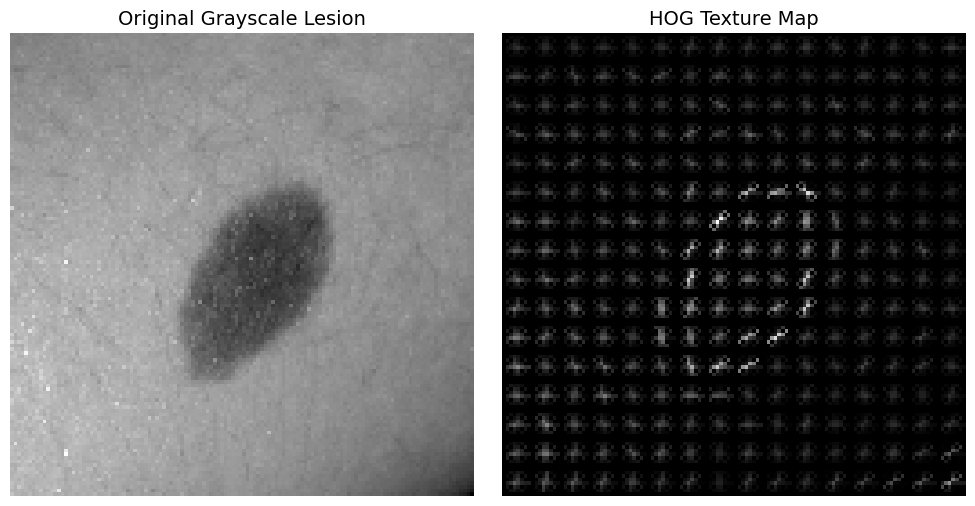

In [7]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import color, exposure, io
import cv2

# Let's say you have a single image loaded called 'sample_lesion'
bening = "PAT_1516_1765_530.png"

img_path = "../data/imgs/" + bening
sample_lesion = io.imread(img_path)

if sample_lesion.shape[-1] == 4:
    sample_lesion = sample_lesion[:, :, :3]
# Pre-process it
gray_image = color.rgb2gray(sample_lesion)
resized_img = cv2.resize(gray_image, (128,128)) # Made it a bit bigger to see the details!

# Run HOG, but this time we turn on `visualize=True`
features, hog_image = hog(resized_img, orientations=9, 
                          pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), 
                          visualize=True, # THIS IS THE MAGIC KEY
                          feature_vector=True)

# Make the lines bright enough to see easily
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Plot them side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(resized_img, cmap=plt.cm.gray)
ax1.set_title('Original Grayscale Lesion', fontsize=14)

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('HOG Texture Map', fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
len(features)

8100

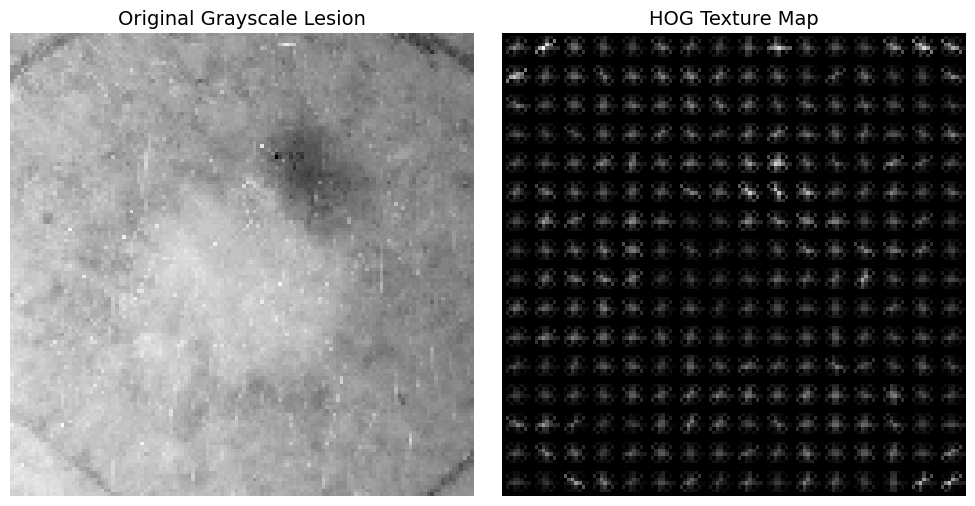

In [9]:
cancerous = "PAT_46_881_939.png"

img_path = "../data/imgs/" + cancerous
sample_lesion = io.imread(img_path)

if sample_lesion.shape[-1] == 4:
    sample_lesion = sample_lesion[:, :, :3]
# Pre-process it
gray_image = color.rgb2gray(sample_lesion)
resized_img = cv2.resize(gray_image, (128, 128)) # Made it a bit bigger to see the details!

# Run HOG, but this time we turn on `visualize=True`
features, hog_image = hog(resized_img, orientations=9, 
                          pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), 
                          visualize=True, # THIS IS THE MAGIC KEY
                          feature_vector=True)

# Make the lines bright enough to see easily
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Plot them side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(resized_img, cmap=plt.cm.gray)
ax1.set_title('Original Grayscale Lesion', fontsize=14)

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('HOG Texture Map', fontsize=14)

plt.tight_layout()
plt.show()

---

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df_og = pd.read_csv("../data/features.csv")
df_og = df_og.drop(columns=["Unnamed: 0","HSV_Hue_Variance","HSV_Value_Variance"])
df_og

,ID,Asymmetry,Border,HSV_Saturation_Variance,Cancerous
0,PAT_1516_1765_530.png,0.132393,0.712,0.004353,0
1,PAT_46_881_939.png,0.320717,0.790,0.020832,1
2,PAT_1545_1867_547.png,0.307012,0.777,0.002434,0
3,PAT_1989_4061_934.png,0.315875,0.680,0.003186,0
4,PAT_684_1302_588.png,0.178256,0.687,0.002111,1
...,...,...,...,...,...
495,PAT_527_1359_165.png,0.194370,0.729,0.006541,1
496,PAT_301_649_533.png,0.333255,0.774,0.009641,1
497,PAT_247_1293_449.png,0.352418,0.719,0.003054,1
498,PAT_995_1867_165.png,1.035729,0.881,0.001832,1


In [13]:
img_list = df_og["ID"].unique()


In [ ]:
hog_list = []
for img in img_list:
    img_path = "../data/imgs/" + img
    sample_lesion = io.imread(img_path)

    if sample_lesion.shape[-1] == 4:
        sample_lesion = sample_lesion[:, :, :3]
    # Pre-process it
    gray_image = color.rgb2gray(sample_lesion)
    resized_img = cv2.resize(gray_image, (64, 64)) 

    # Run HOG, but this time we turn on `visualize=True`
    feature = hog(resized_img, orientations=9, 
                            pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2)
                            )
    
    hog_list.append(feature)

In [15]:
hog_df = pd.DataFrame(hog_list)
hog_df

,0,1,2,3,4,5,6,7,8,9,...,1754,1755,1756,1757,1758,1759,1760,1761,1762,1763
0,0.230689,0.093690,0.099958,0.230689,0.230689,0.039311,0.103956,0.230689,0.073947,0.176650,...,0.033224,0.264786,0.264786,0.264786,0.264786,0.264786,0.055910,0.000000,0.000000,0.000000
1,0.247856,0.160827,0.247856,0.247856,0.247856,0.102536,0.148038,0.192352,0.059931,0.247856,...,0.170951,0.239883,0.239883,0.239883,0.239883,0.239883,0.034504,0.038055,0.168348,0.065653
2,0.316533,0.155753,0.117611,0.275148,0.181825,0.070992,0.075132,0.124794,0.255716,0.189502,...,0.146248,0.228306,0.188155,0.138498,0.103875,0.204133,0.111574,0.096610,0.122572,0.172627
3,0.227497,0.017799,0.211964,0.129506,0.227497,0.203494,0.221515,0.069833,0.181687,0.227497,...,0.247604,0.247604,0.154569,0.160280,0.079569,0.247604,0.035485,0.118697,0.122048,0.052036
4,0.107002,0.166246,0.140080,0.067246,0.238796,0.039814,0.201048,0.104233,0.157543,0.238796,...,0.165879,0.221994,0.018677,0.227129,0.059696,0.227129,0.227129,0.026480,0.038465,0.219437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.198520,0.190237,0.076028,0.094871,0.233948,0.055334,0.131026,0.132561,0.110634,0.233948,...,0.137471,0.232535,0.207690,0.232535,0.174453,0.232535,0.079703,0.151419,0.123358,0.040164
496,0.100642,0.134573,0.176308,0.102515,0.121558,0.152711,0.091185,0.190728,0.108503,0.177470,...,0.159436,0.253274,0.102768,0.179052,0.081398,0.161615,0.196075,0.068492,0.049340,0.253274
497,0.123777,0.159948,0.060793,0.169178,0.140846,0.080184,0.094332,0.089070,0.158828,0.239231,...,0.158127,0.228853,0.147931,0.036929,0.156643,0.228853,0.082444,0.082656,0.042214,0.088041
498,0.220060,0.134254,0.201361,0.140782,0.220060,0.089714,0.163563,0.030035,0.220060,0.186886,...,0.222597,0.173828,0.113781,0.197045,0.041333,0.222597,0.129403,0.132917,0.122590,0.043393


In [16]:
combined_df = pd.concat([df_og.reset_index(drop=True), hog_df.reset_index(drop=True)], axis=1)
combined_df

,ID,Asymmetry,Border,HSV_Saturation_Variance,Cancerous,0,1,2,3,4,...,1754,1755,1756,1757,1758,1759,1760,1761,1762,1763
0,PAT_1516_1765_530.png,0.132393,0.712,0.004353,0,0.230689,0.093690,0.099958,0.230689,0.230689,...,0.033224,0.264786,0.264786,0.264786,0.264786,0.264786,0.055910,0.000000,0.000000,0.000000
1,PAT_46_881_939.png,0.320717,0.790,0.020832,1,0.247856,0.160827,0.247856,0.247856,0.247856,...,0.170951,0.239883,0.239883,0.239883,0.239883,0.239883,0.034504,0.038055,0.168348,0.065653
2,PAT_1545_1867_547.png,0.307012,0.777,0.002434,0,0.316533,0.155753,0.117611,0.275148,0.181825,...,0.146248,0.228306,0.188155,0.138498,0.103875,0.204133,0.111574,0.096610,0.122572,0.172627
3,PAT_1989_4061_934.png,0.315875,0.680,0.003186,0,0.227497,0.017799,0.211964,0.129506,0.227497,...,0.247604,0.247604,0.154569,0.160280,0.079569,0.247604,0.035485,0.118697,0.122048,0.052036
4,PAT_684_1302_588.png,0.178256,0.687,0.002111,1,0.107002,0.166246,0.140080,0.067246,0.238796,...,0.165879,0.221994,0.018677,0.227129,0.059696,0.227129,0.227129,0.026480,0.038465,0.219437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,PAT_527_1359_165.png,0.194370,0.729,0.006541,1,0.198520,0.190237,0.076028,0.094871,0.233948,...,0.137471,0.232535,0.207690,0.232535,0.174453,0.232535,0.079703,0.151419,0.123358,0.040164
496,PAT_301_649_533.png,0.333255,0.774,0.009641,1,0.100642,0.134573,0.176308,0.102515,0.121558,...,0.159436,0.253274,0.102768,0.179052,0.081398,0.161615,0.196075,0.068492,0.049340,0.253274
497,PAT_247_1293_449.png,0.352418,0.719,0.003054,1,0.123777,0.159948,0.060793,0.169178,0.140846,...,0.158127,0.228853,0.147931,0.036929,0.156643,0.228853,0.082444,0.082656,0.042214,0.088041
498,PAT_995_1867_165.png,1.035729,0.881,0.001832,1,0.220060,0.134254,0.201361,0.140782,0.220060,...,0.222597,0.173828,0.113781,0.197045,0.041333,0.222597,0.129403,0.132917,0.122590,0.043393


In [17]:
#combined_df.to_csv("../data/hog_features.csv", index=False)

---

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
combined_df = pd.read_csv("../data/hog_features.csv")
combined_df.columns = combined_df.columns.astype(str)


X = combined_df.drop(columns=['Cancerous', 'ID', 'Unnamed: 0'], errors='ignore')
y = combined_df['Cancerous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

n_estimators = 10 - train_acc: 0.975 - val_acc: 0.560
n_estimators = 50 - train_acc: 1.000 - val_acc: 0.530
n_estimators = 100 - train_acc: 1.000 - val_acc: 0.580
n_estimators = 250 - train_acc: 1.000 - val_acc: 0.670
n_estimators = 500 - train_acc: 1.000 - val_acc: 0.650
n_estimators = 750 - train_acc: 1.000 - val_acc: 0.650
n_estimators = 1000 - train_acc: 1.000 - val_acc: 0.650

max_depth_metrics = 3 - train_acc: 1.000 - val_acc: 0.570
max_depth_metrics = 4 - train_acc: 1.000 - val_acc: 0.600
max_depth_metrics = 5 - train_acc: 1.000 - val_acc: 0.710
max_depth_metrics = 6 - train_acc: 1.000 - val_acc: 0.690
max_depth_metrics = 7 - train_acc: 1.000 - val_acc: 0.650
max_depth_metrics = 8 - train_acc: 1.000 - val_acc: 0.640
max_depth_metrics = None - train_acc: 1.000 - val_acc: 0.670


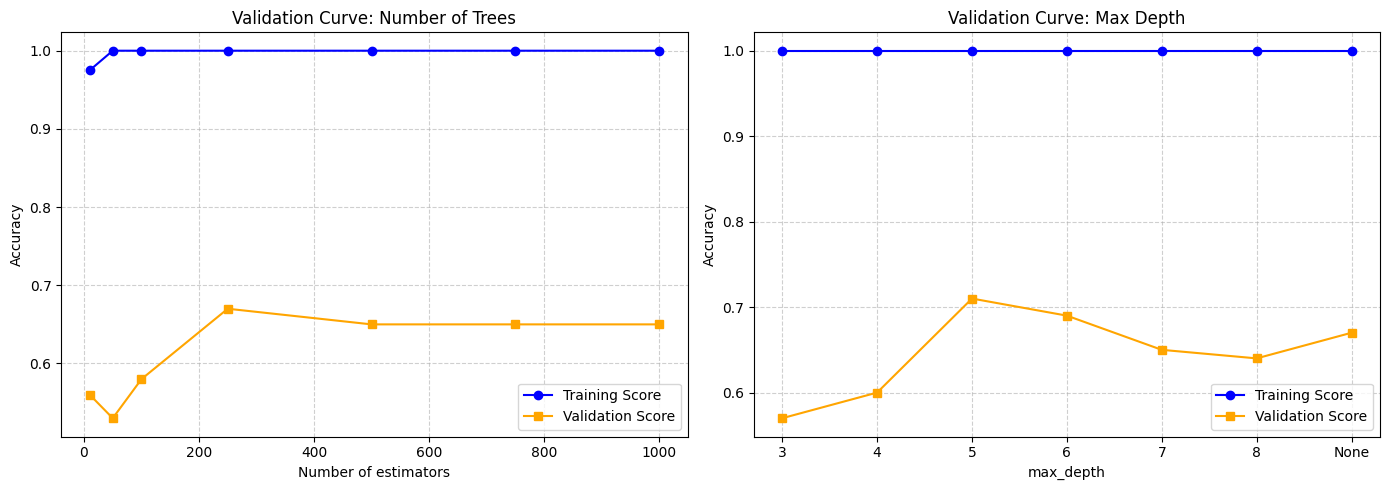

In [4]:
n_est_metrics = {"train":[], "val":[]}
max_depth_metrics = {"train":[], "val":[]}
n_estimator = [10, 50, 100,250, 500, 750, 1000]
depth_list = [3, 4, 5, 6, 7, 8, None]

for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    val_acc = rf.score(X_test, y_test)
    n_est_metrics["train"].append(train_acc)
    n_est_metrics["val"].append(val_acc)
    print(f"n_estimators = {n} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")

print("")
for d in depth_list:
    rf = RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42, max_depth=d)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    val_acc = rf.score(X_test, y_test)
    max_depth_metrics["train"].append(train_acc)
    max_depth_metrics["val"].append(val_acc)
    print(f"max_depth_metrics = {d} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")



# Set up a wide canvas with 2 side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Number of Trees (n_estimators) ---
ax[0].plot(n_estimator, n_est_metrics["train"], marker='o', label="Training Score", color="blue")
ax[0].plot(n_estimator, n_est_metrics["val"], marker='s', label="Validation Score", color="orange")
ax[0].set_title("Validation Curve: Number of Trees")
ax[0].set_xlabel("Number of estimators")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

# --- PLOT 2: Maximum Depth (max_depth) ---
# Convert 'None' to a string so matplotlib can plot it on the x-axis
depth_labels = [str(d) for d in depth_list]

ax[1].plot(depth_labels, max_depth_metrics["train"], marker='o', label="Training Score", color="blue")
ax[1].plot(depth_labels, max_depth_metrics["val"], marker='s', label="Validation Score", color="orange")
ax[1].set_title("Validation Curve: Max Depth")
ax[1].set_xlabel("max_depth")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

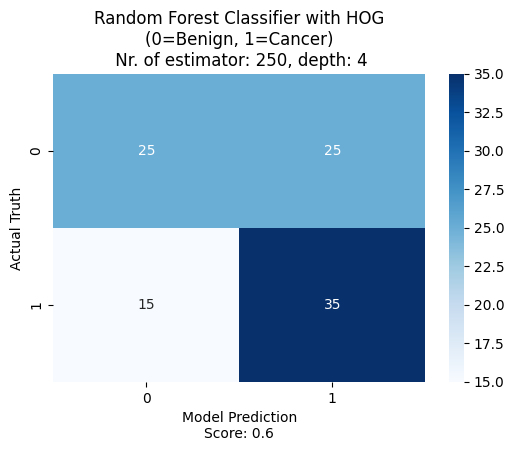

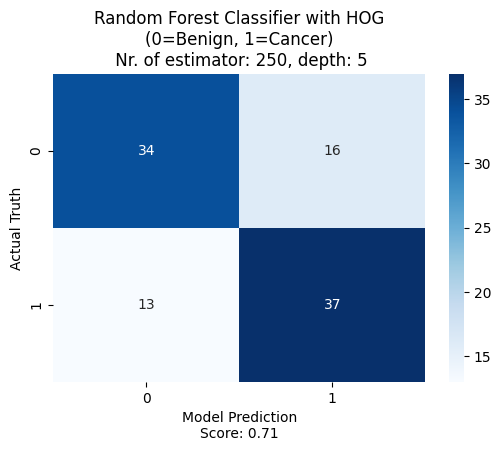

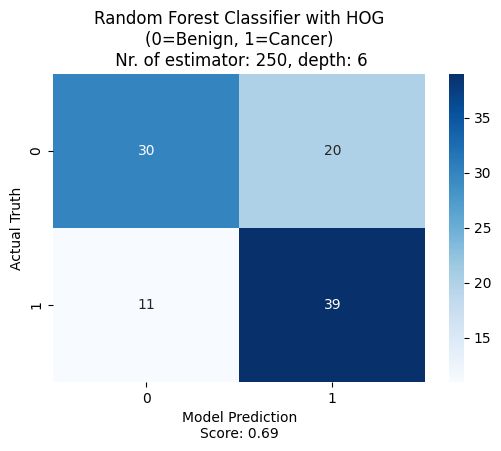

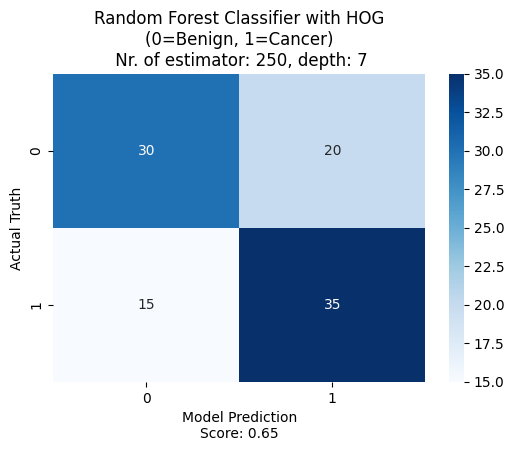

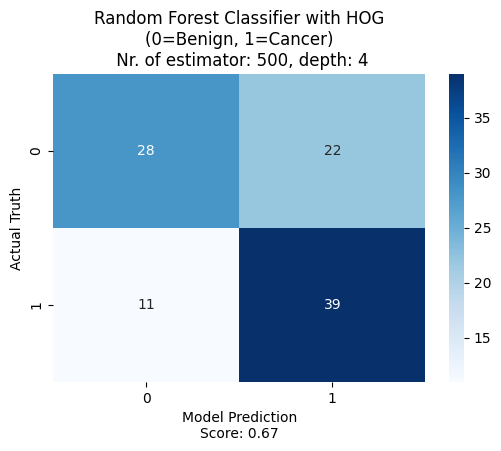

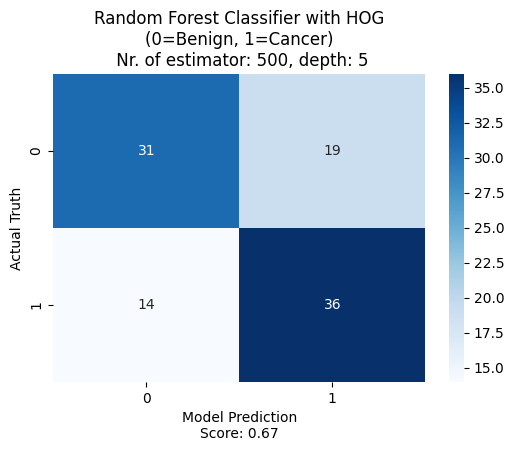

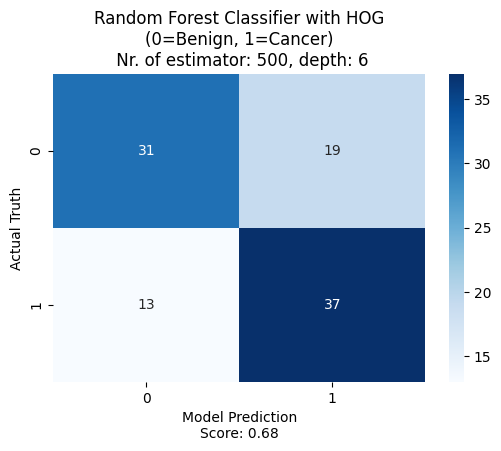

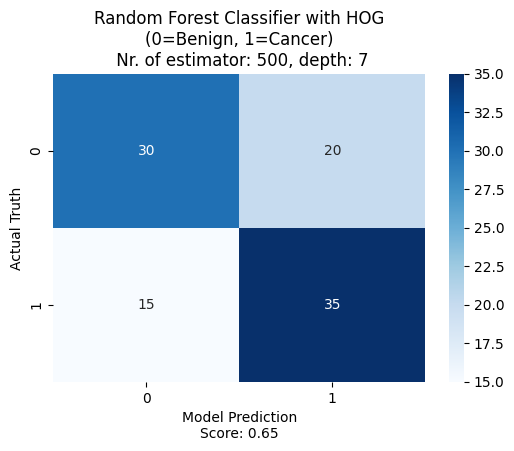

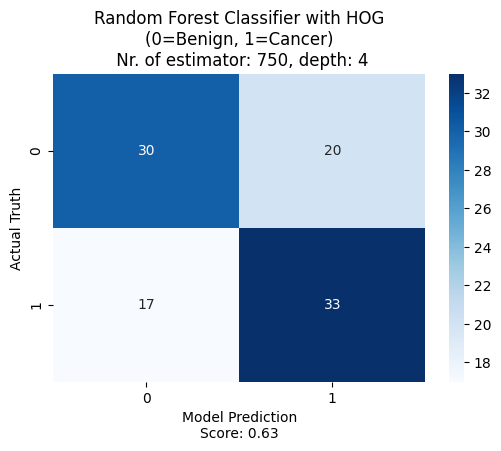

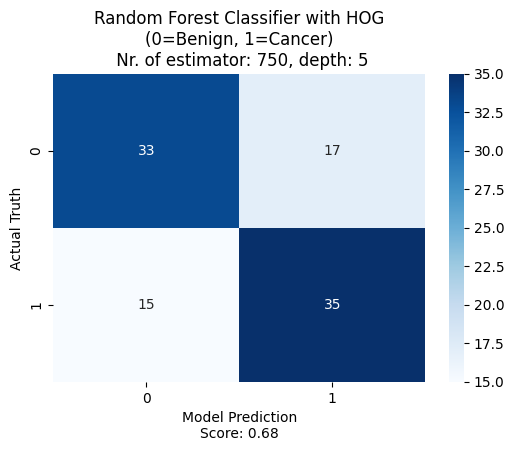

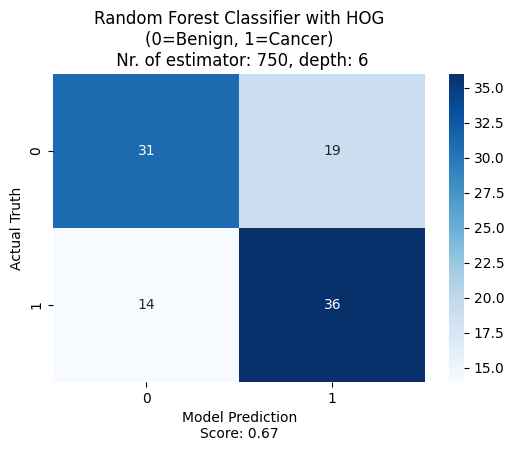

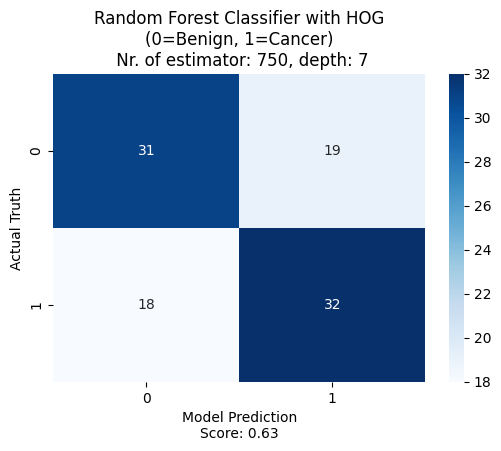

In [5]:
final_estimators = [250, 500, 750]
final_depth = [4, 5, 6, 7]

for n in final_estimators:
    for d in final_depth:

        # Train the Forest
        rf_final = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42, max_depth=d)
        rf_final.fit(X_train, y_train)

        # Predict and Evaluate
        final_preds = rf_final.predict(X_test)
        # print(f"\nFinal Accuracy: {accuracy_score(y_test, final_preds):.3f}")
        # print(classification_report(y_test, final_preds))

        # Draw the Confusion Matrix
        plt.figure(figsize=(6,4))
        sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
        plt.title(f"Random Forest Classifier with HOG\n(0=Benign, 1=Cancer)\n Nr. of estimator: {n}, depth: {d}")
        plt.ylabel('Actual Truth')
        plt.xlabel(f'Model Prediction\nScore: {rf_final.score(X_test, y_test)}')
        plt.savefig(f"../results/predictions/hog/conf_matrix_{n}_estim_{d}_depth.png", dpi = 200, bbox_inches = "tight")
        

---